In [158]:
import ee
import geopandas as gpd
import requests
from PIL import Image
from io import BytesIO
from pathlib import Path
import matplotlib.pyplot as plt


# Authenticate and initialize Earth Engine
ee.Authenticate()
ee.Initialize(project="acm-research-f26")
print("Google Earth Engine initialized successfully.")

Google Earth Engine initialized successfully.


In [312]:
#load data
gdf = gpd.read_file(
    "./Data/im3_dataset.gpkg",
    layer="building"
)

gdf = gdf.to_crs(epsg=4326)

In [401]:
#select random data centers.
data_center = (
    gdf
    .dropna(subset=["geometry"])
    .sample(n=1)
    .iloc[0]
)

# get center point of building polygon
building_center = data_center.geometry.centroid

lon = building_center.x
lat = building_center.y

print("Name:", data_center["name"])
print("State:", data_center["state"])
print("Coordinates:", lon, lat)

Name: VISA
State: Illinois
Coordinates: -87.95284650850378 42.21675653596632


In [402]:
center = ee.Geometry.Point([lon, lat])

#radius around data center
buffer_meters = 500

region = center.buffer(buffer_meters).bounds()

In [403]:
def get_latest_naip_image(region, start_year=2026, earliest_year=2020):
    for year in range(start_year, earliest_year - 1, -1):
        naip = (
            ee.ImageCollection("USDA/NAIP/DOQQ")
            .filterBounds(region)
            .filterDate(f"{year}-01-01", f"{year + 1}-01-01")
            .sort("system:time_start", False)

        )
        image_count = naip.size().getInfo()
        print(f"Year: {year}, Image Count: {image_count}")

        if image_count > 0:
            image = ee.Image(naip.first())
            date = (
                ee.Date(image.get("system:time_start"))
                .format("YYYY-MM-dd")
                .getInfo()
            )
            return image, date, year
    return None, None, None

Year: 2026, Image Count: 0
Year: 2025, Image Count: 0
Year: 2024, Image Count: 0
Year: 2023, Image Count: 1
Image saved to: Data/temp/VISA_2023-07-10.png


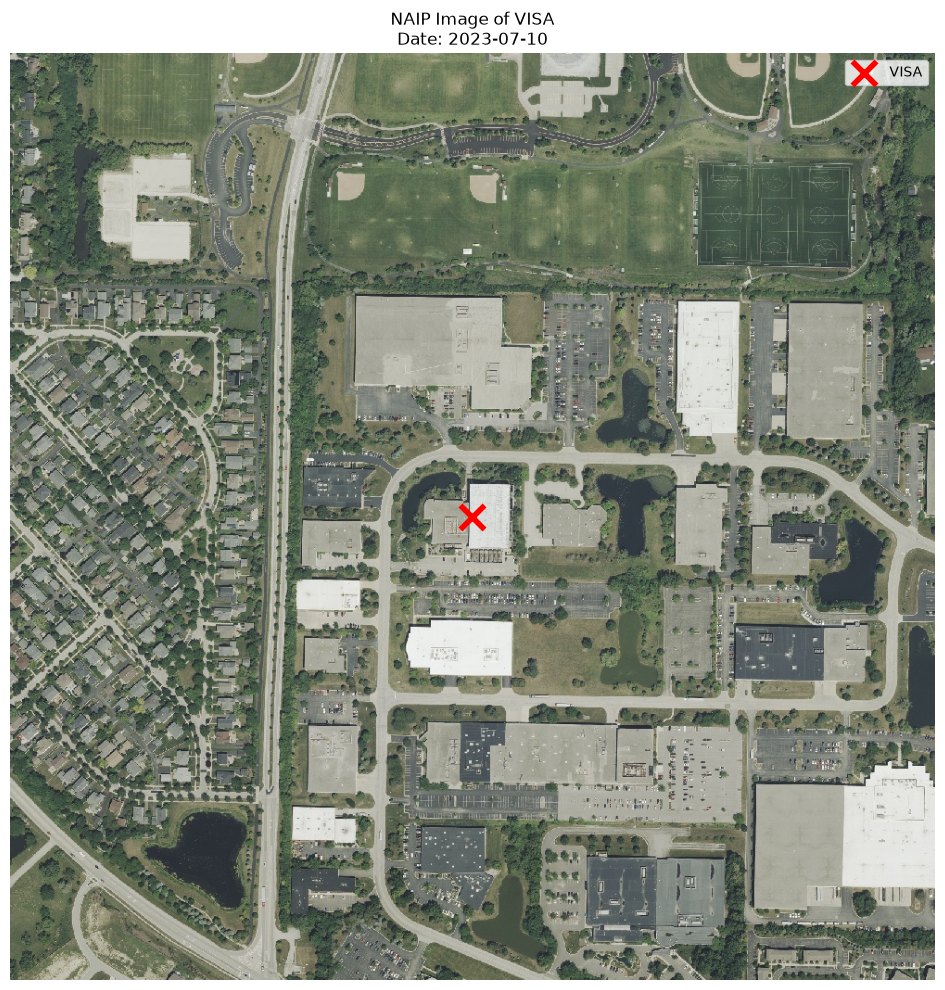

In [404]:
image, date, year = get_latest_naip_image(region)
if image is None:
    raise ValueError("No NAIP images found between 2020 and 2026.")

rgb = image.select([
    "R",
    "G",
    "B"
])

#download preview image from Earth Engine
vis_params = {
    "bands": ["R", "G", "B"],
    "min": 0,
    "max": 255,
    "dimensions": 1000,
    "region": region
}

url = rgb.getThumbURL(vis_params)

response = requests.get(url)
response.raise_for_status()

satellite_image = Image.open(
    BytesIO(response.content)
)

#save image to temp folder

temp_folder = Path("./Data/temp")
temp_folder.mkdir(parents=True, exist_ok=True)

safe_name = str(data_center["name"]).replace("/", "_").replace(" ", "_")

file_path = temp_folder / f"{safe_name}_{date}.png"

satellite_image.save(file_path)

print("Image saved to:", file_path)



#display image 
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(satellite_image)
# image dimensions
width, height = satellite_image.size

# get geographic bounds of image
bounds = region.bounds().coordinates().getInfo()[0]

# bounding box coordinates
min_lon = bounds[0][0]
min_lat = bounds[0][1]

max_lon = bounds[2][0]
max_lat = bounds[2][1]

# convert data center lon/lat to image pixel coordinates
center_x = ((lon - min_lon) / (max_lon - min_lon)) * width

center_y = ((max_lat - lat) / (max_lat - min_lat)) * height

# x on data center
ax.scatter(

    center_x,
    center_y,
    marker="x",
    s=300,
    color="red",
    linewidths=4,
    zorder=10,
    label=data_center["name"]
)


ax.set_title(
    f"NAIP Image of {data_center['name']}\n"
    f"Date: {date}"

)

ax.legend()
ax.axis("off")
plt.tight_layout()
plt.show()